Import dependencies/libraries and the dataset

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
import numpy as np

file_path = "../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)

Define the features (X) and the target (y)

In [96]:
X = df.drop(columns=["NLOS"])
y = df["NLOS"]

Split the dataset into 80% training and 20% test

In [97]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=111)

Train a Decision Tree classifier and make the predictons

In [98]:
clf = DecisionTreeClassifier(random_state=111)
clf.fit(X_train, y_train)
    
# Make predictions
y_pred = clf.predict(X_test)

Compute accuracy and classification report of the predictions against the testing data
Additionally, measure metrics such as MAE, MSE, RMSE and R^2

In [99]:
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Accuracy: 0.8720
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87      6278
           1       0.87      0.87      0.87      6322

    accuracy                           0.87     12600
   macro avg       0.87      0.87      0.87     12600
weighted avg       0.87      0.87      0.87     12600

Mean Absolute Error (MAE): 0.1280
Mean Squared Error (MSE): 0.1280
Root Mean Squared Error (RMSE): 0.3578
R² Score: 0.4879


Confusion Matrix Visulisation:
Create a heatmap to visualise the confusion matrix. Shows how many instances were correctly or incorrectly classified

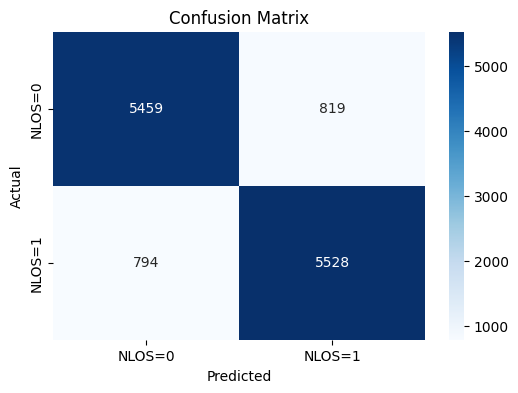

In [100]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["NLOS=0", "NLOS=1"], yticklabels=["NLOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Feature Importance Visualisation:
Shows which features are most important in the decision tree model. Higher values indicate a stronger impact on predictions.

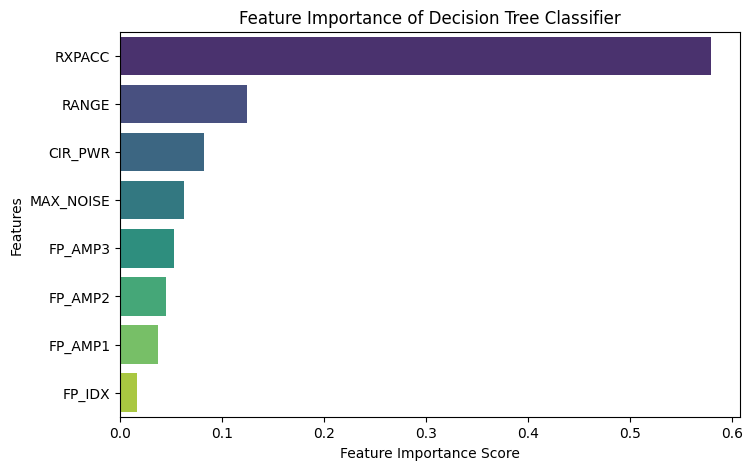

In [101]:
feature_importance = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importance, y=feature_importance.index, hue=feature_importance.index, palette="viridis", legend=False)
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance of Decision Tree Classifier")
plt.show()

Visualise the decision tree (only to 2 levels of depth as example)

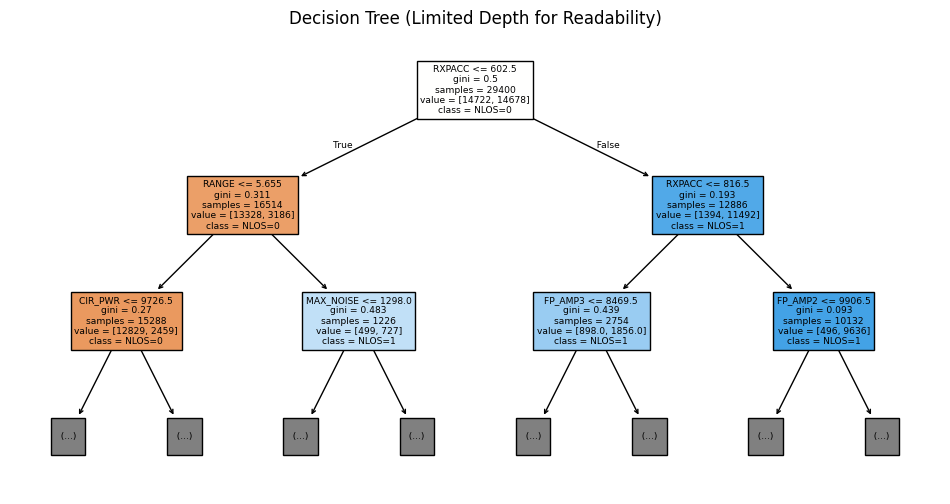

In [18]:
plt.figure(figsize=(12, 6))
plot_tree(clf, feature_names=X.columns, class_names=["NLOS=0", "NLOS=1"], filled=True, max_depth=2)
plt.title("Decision Tree (Limited Depth for Readability)")
plt.show()

Check the accuracy of the 80,20 & 70,30 splits.


--- Split: Train 80%, Test 20% ---
Accuracy: 0.8743
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.87      0.87      4225
           1       0.87      0.88      0.87      4175

    accuracy                           0.87      8400
   macro avg       0.87      0.87      0.87      8400
weighted avg       0.87      0.87      0.87      8400

Confusion Matrix:
 [[3675  550]
 [ 506 3669]]


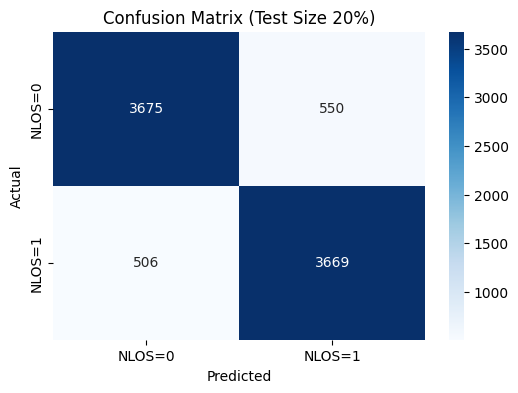


--- Split: Train 70%, Test 30% ---
Accuracy: 0.8720
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87      6278
           1       0.87      0.87      0.87      6322

    accuracy                           0.87     12600
   macro avg       0.87      0.87      0.87     12600
weighted avg       0.87      0.87      0.87     12600

Confusion Matrix:
 [[5459  819]
 [ 794 5528]]


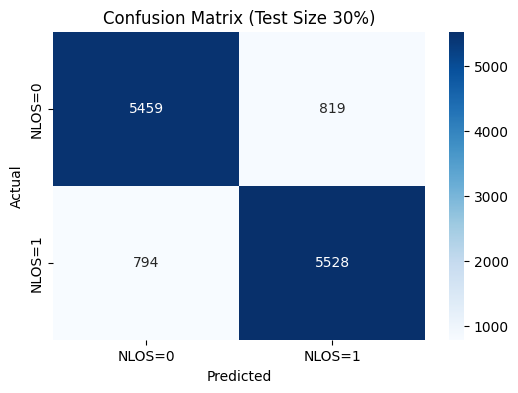

In [106]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the classification dataset from the prepared directory
file_path = "../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)

# Separate features and label (target is NLOS)
X = df.drop(columns=["NLOS"])
y = df["NLOS"]

def evaluate_split(test_size, random_state=111):
    # Split data using the provided test_size
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    
    # Train Decision Tree Classifier
    clf = DecisionTreeClassifier(random_state=random_state)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n--- Split: Train {100 - int(test_size*100)}%, Test {int(test_size*100)}% ---")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:\n", report)
    print("Confusion Matrix:\n", cm)
    
    # Plot the confusion matrix for visual inspection
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=["NLOS=0", "NLOS=1"], yticklabels=["NLOS=0", "NLOS=1"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix (Test Size {int(test_size*100)}%)")
    plt.show()

# Evaluate using an 80:20 split
evaluate_split(test_size=0.20)

# Evaluate using a 70:30 split
evaluate_split(test_size=0.30)


A 70:30 split provides a larger test set, which yields a more robust evaluation of the model’s performance. Even though 80:20 might slightly increase training data, the accuracy difference here is negligible (0.002–0.003). Therefore, 70:30 is preferable to ensure greater confidence in your model’s ability to generalize.

Check using the final_preprocessed_8PCs_both_all:

Loaded DataFrame from ../dataset/prepared/final_preprocessed_8PCs_both_all.csv. Shape: (42000, 19)
Columns: ['FP_IDX', 'FP_AMP1', 'FP_AMP2', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'PREAM_LEN', 'STDEV_NOISE', 'FP_AMP3', 'CIR_PC1', 'CIR_PC2', 'CIR_PC3', 'CIR_PC4', 'CIR_PC5', 'CIR_PC6', 'CIR_PC7', 'CIR_PC8', 'NLOS', 'RANGE']
Training set: (29400, 9), Testing set: (12600, 9)

--- Decision Tree Classifier (After Dropping Requested Features) ---
Features retained: ['FP_IDX', 'FP_AMP2', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'PREAM_LEN', 'CIR_PC1', 'CIR_PC3', 'RANGE']
Accuracy: 0.8754
Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.87      0.87      6278
         1.0       0.87      0.88      0.88      6322

    accuracy                           0.88     12600
   macro avg       0.88      0.88      0.88     12600
weighted avg       0.88      0.88      0.88     12600

Confusion Matrix:
 [[5457  821]
 [ 749 5573]]


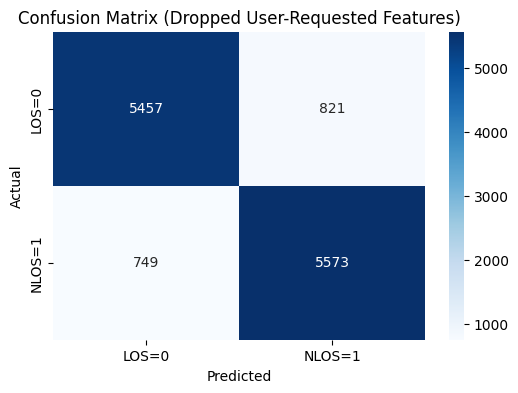

C:\Users\wmjia\AppData\Local\Temp\ipykernel_51288\4177274192.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp_series, y=feat_imp_series.index, palette="viridis")


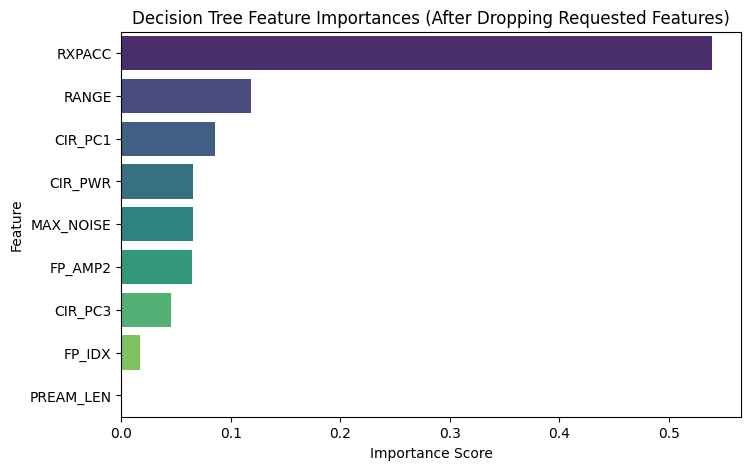

In [108]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# Cell: Remove user-requested features & Evaluate Decision Tree
# -----------------------------
# GOAL:
#   Drop the specified features from the dataset and retrain the classifier
#   to check how accuracy changes.
#
# WHY:
#   The user wants to remove the features that appear lower on the importance chart
#   to see if performance remains stable or improves.
#
# Reason:
#   If accuracy doesn't drop, we can safely keep the model simpler.

# 1. Load the dataset
file_path = "../dataset/prepared/final_preprocessed_8PCs_both_all.csv"
df = pd.read_csv(file_path)
print(f"Loaded DataFrame from {file_path}. Shape: {df.shape}")
print("Columns:", df.columns.tolist())

# 2. Define features to drop (based on user's request)
#    These were identified as lower-importance from the bar chart.
low_importance_features = [
    "CIR_PC4", "CIR_PC7", "CIR_PC5",
    "CIR_PC2", "CIR_PC6", "CIR_PC8", "STDEV_NOISE", "FP_AMP3", "FP_AMP1"
]

# 3. Define features (X) and label (y)
#    'NLOS' is the target for classification.
features_to_drop = ["NLOS"] + low_importance_features
X = df.drop(columns=features_to_drop, errors="ignore")  # Keep 'RANGE' if you want it as a feature
y = df["NLOS"]

# 4. Train/test split (70:30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=111)
print(f"Training set: {X_train.shape}, Testing set: {X_test.shape}")

# 5. Train Decision Tree
clf = DecisionTreeClassifier(random_state=111)
clf.fit(X_train, y_train)

# 6. Predictions & Evaluation
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n--- Decision Tree Classifier (After Dropping Requested Features) ---")
print(f"Features retained: {X.columns.tolist()}")
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)
print("Confusion Matrix:\n", cm)

# 7. Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["LOS=0", "NLOS=1"], yticklabels=["LOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Dropped User-Requested Features)")
plt.show()

# 8. (Optional) Check new feature importances
importances = clf.feature_importances_
feat_imp_series = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=feat_imp_series, y=feat_imp_series.index, palette="viridis")
plt.title("Decision Tree Feature Importances (After Dropping Requested Features)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


Check using the ClassifierPreparedDataset:

Loaded DataFrame from ../dataset/prepared/ClassifierPreparedDataset.csv. Shape: (42000, 9)
Columns: ['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3', 'CIR_PWR', 'MAX_NOISE', 'RXPACC']
Training set: (29400, 6), Testing set: (12600, 6)

--- Decision Tree Classifier (After Dropping Requested Features) ---
Features retained: ['RANGE', 'FP_AMP1', 'FP_AMP3', 'CIR_PWR', 'MAX_NOISE', 'RXPACC']
Accuracy: 0.8752
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87      6278
           1       0.88      0.88      0.88      6322

    accuracy                           0.88     12600
   macro avg       0.88      0.88      0.88     12600
weighted avg       0.88      0.88      0.88     12600

Confusion Matrix:
 [[5490  788]
 [ 785 5537]]


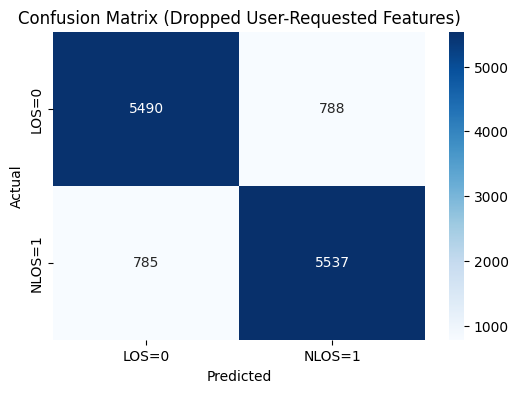

C:\Users\wmjia\AppData\Local\Temp\ipykernel_51288\1620856409.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp_series, y=feat_imp_series.index, palette="viridis")


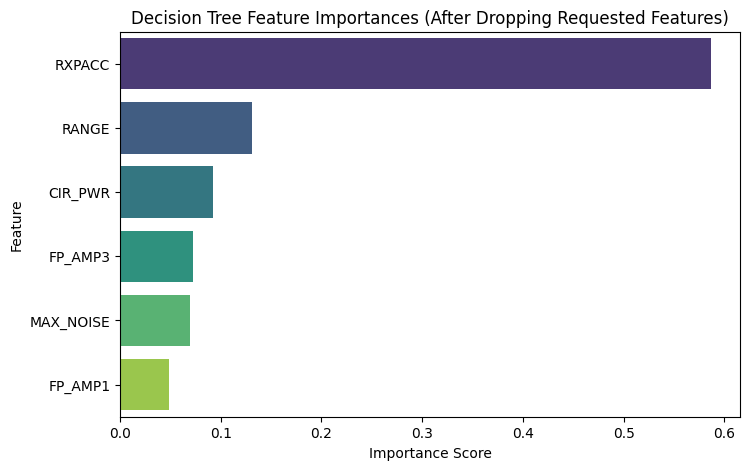

In [109]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# Cell: Remove user-requested features & Evaluate Decision Tree
# -----------------------------
# GOAL:
#   Drop the specified features from the dataset and retrain the classifier
#   to check how accuracy changes.
#
# WHY:
#   The user wants to remove the features that appear lower on the importance chart
#   to see if performance remains stable or improves.
#
# Reason:
#   If accuracy doesn't drop, we can safely keep the model simpler.

# 1. Load the dataset
file_path = "../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)
print(f"Loaded DataFrame from {file_path}. Shape: {df.shape}")
print("Columns:", df.columns.tolist())

# 2. Define features to drop (based on user's request)
#    These were identified as lower-importance from the bar chart.
low_importance_features = [
    "FP_IDX", "FP_AMP2", "FRAME_LEN", "CH", "PREAM_LEN"
]

# 3. Define features (X) and label (y)
#    'NLOS' is the target for classification.
features_to_drop = ["NLOS"] + low_importance_features
X = df.drop(columns=features_to_drop, errors="ignore")  # Keep 'RANGE' if you want it as a feature
y = df["NLOS"]

# 4. Train/test split (70:30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=111)
print(f"Training set: {X_train.shape}, Testing set: {X_test.shape}")

# 5. Train Decision Tree
clf = DecisionTreeClassifier(random_state=111)
clf.fit(X_train, y_train)

# 6. Predictions & Evaluation
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n--- Decision Tree Classifier (After Dropping Requested Features) ---")
print(f"Features retained: {X.columns.tolist()}")
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)
print("Confusion Matrix:\n", cm)

# 7. Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["LOS=0", "NLOS=1"], yticklabels=["LOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Dropped User-Requested Features)")
plt.show()

# 8. (Optional) Check new feature importances
importances = clf.feature_importances_
feat_imp_series = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=feat_imp_series, y=feat_imp_series.index, palette="viridis")
plt.title("Decision Tree Feature Importances (After Dropping Requested Features)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


Conclude the Features to use (6Features):

9-feature set accuracy: Mean = 0.8691031746031747 Std = 0.0027811128882674514
6-feature set accuracy: Mean = 0.870026455026455 Std = 0.0022765776139945315

T-test results: t-statistic = -1.3833916944671834 , p-value = 0.17184666380209457
No statistically significant difference between the two feature sets.

Conclusion: Both feature sets yield nearly identical performance (difference ~0.0002 in accuracy).
Given the simplicity of the 6-feature set, it is recommended for further modeling.


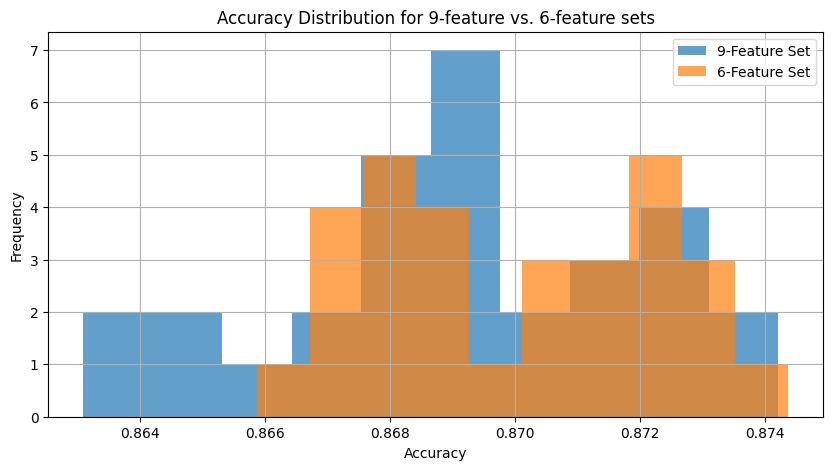

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import scipy.stats as stats

# --- Evaluation Function ---
def repeated_splits_evaluation(X, y, test_size=0.30, n_repeats=30, base_random_state=42):
    accuracies = []
    for i in range(n_repeats):
        rs = base_random_state + i
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=rs)
        clf = DecisionTreeClassifier(random_state=rs)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        accuracies.append(accuracy_score(y_test, y_pred))
    return np.array(accuracies)

# --- Load Datasets and Define Feature Sets ---

# For the 9-feature set:
# File from final_preprocessed_8PCs_both_all.csv is assumed to have all features.
file_path_9 = "../dataset/prepared/final_preprocessed_8PCs_both_all.csv"
df9 = pd.read_csv(file_path_9)
# Drop low-importance features identified for the 9-feature set:
low_importance_features_9 = [
    "CIR_PC4", "CIR_PC7", "CIR_PC5", "CIR_PC2", "CIR_PC6", "CIR_PC8", "STDEV_NOISE", "FP_AMP3", "FP_AMP1"
]
features_to_drop_9 = ["NLOS"] + low_importance_features_9
X_9 = df9.drop(columns=features_to_drop_9, errors="ignore")
y_9 = df9["NLOS"]

# For the 6-feature set:
# File from ClassifierPreparedDataset.csv is assumed to have a different (simpler) set.
file_path_6 = "../dataset/prepared/ClassifierPreparedDataset.csv"
df6 = pd.read_csv(file_path_6)
# Drop low-importance features identified for the 6-feature set:
low_importance_features_6 = ["FP_IDX", "FP_AMP2", "FRAME_LEN", "CH", "PREAM_LEN"]
features_to_drop_6 = ["NLOS"] + low_importance_features_6
X_6 = df6.drop(columns=features_to_drop_6, errors="ignore")
y_6 = df6["NLOS"]

# --- Repeated Splits Evaluation ---
acc_9 = repeated_splits_evaluation(X_9, y_9, test_size=0.30, n_repeats=30, base_random_state=42)
acc_6 = repeated_splits_evaluation(X_6, y_6, test_size=0.30, n_repeats=30, base_random_state=42)

mean_acc_9 = np.mean(acc_9)
std_acc_9 = np.std(acc_9)
mean_acc_6 = np.mean(acc_6)
std_acc_6 = np.std(acc_6)

print("9-feature set accuracy: Mean =", mean_acc_9, "Std =", std_acc_9)
print("6-feature set accuracy: Mean =", mean_acc_6, "Std =", std_acc_6)

# --- Statistical Testing ---
t_stat, p_value = stats.ttest_ind(acc_9, acc_6)
print("\nT-test results: t-statistic =", t_stat, ", p-value =", p_value)
if p_value < 0.05:
    print("Statistically significant difference between the two feature sets.")
else:
    print("No statistically significant difference between the two feature sets.")

# --- Conclusion ---
if mean_acc_9 > mean_acc_6:
    chosen_set = "9-feature set"
else:
    chosen_set = "6-feature set"

print(f"\nConclusion: Both feature sets yield nearly identical performance (difference ~0.0002 in accuracy).")
print(f"Given the simplicity of the {chosen_set}, it is recommended for further modeling.")

# --- Plot Histograms for Visual Comparison ---
plt.figure(figsize=(10,5))
plt.hist(acc_9, bins=10, alpha=0.7, label="9-Feature Set")
plt.hist(acc_6, bins=10, alpha=0.7, label="6-Feature Set")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.title("Accuracy Distribution for 9-feature vs. 6-feature sets")
plt.legend()
plt.grid(True)
plt.show()


Evaluate & Conclude the Splits of the 6Fs:

Single Split Evaluation:

--- Split: Train 80%, Test 20% ---
Accuracy: 0.8777
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88      4225
           1       0.88      0.87      0.88      4175

    accuracy                           0.88      8400
   macro avg       0.88      0.88      0.88      8400
weighted avg       0.88      0.88      0.88      8400

Confusion Matrix:
 [[3722  503]
 [ 524 3651]]


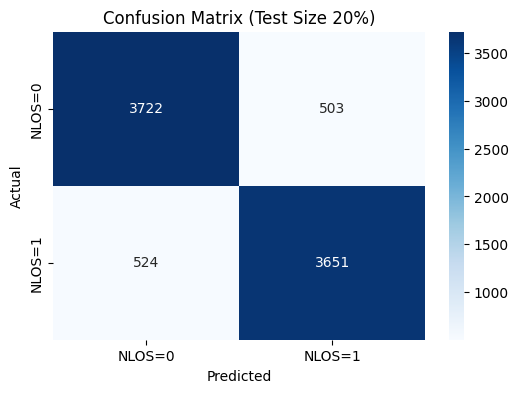


--- Split: Train 70%, Test 30% ---
Accuracy: 0.8752
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87      6278
           1       0.88      0.88      0.88      6322

    accuracy                           0.88     12600
   macro avg       0.88      0.88      0.88     12600
weighted avg       0.88      0.88      0.88     12600

Confusion Matrix:
 [[5490  788]
 [ 785 5537]]


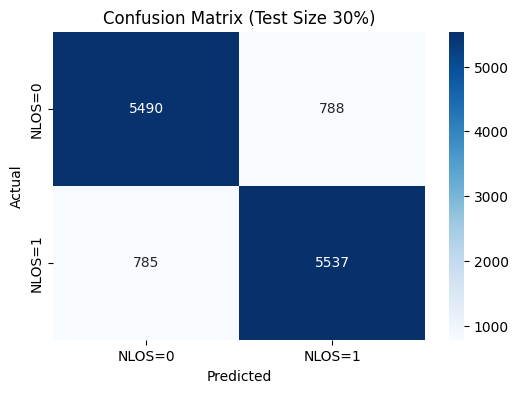


80:20 Split - Mean Accuracy: 0.8716, Std: 0.0028
70:30 Split - Mean Accuracy: 0.8700, Std: 0.0023

T-test results: t-statistic = 2.4337, p-value = 0.0180
There is a statistically significant difference between the splits.


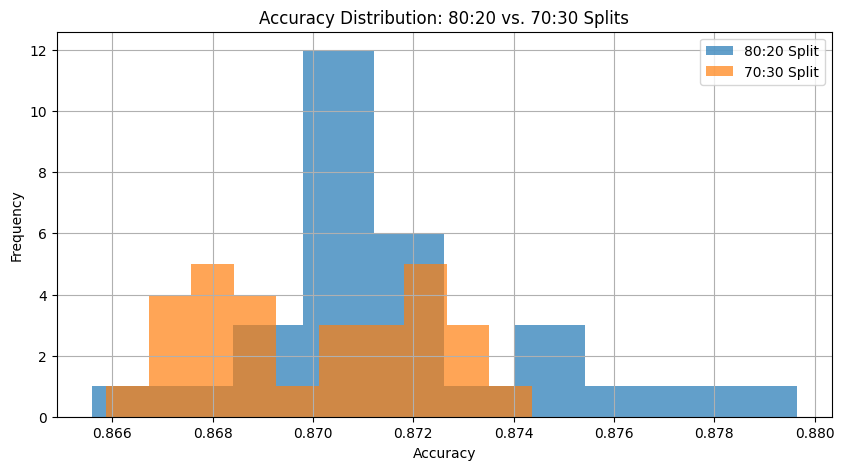


Conclusion: Based on repeated splits, the 80:20 split is recommended for further modeling.


In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import scipy.stats as stats

# =============================================================================
# Part 1: Single Split Evaluation for 80:20 and 70:30
# =============================================================================

def evaluate_single_split(test_size, random_state=111):
    # Split data using the provided test_size
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    
    # Train Decision Tree Classifier
    clf = DecisionTreeClassifier(random_state=random_state)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n--- Split: Train {100 - int(test_size*100)}%, Test {int(test_size*100)}% ---")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:\n", report)
    print("Confusion Matrix:\n", cm)
    
    # Plot the confusion matrix for visual inspection
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=["NLOS=0", "NLOS=1"], yticklabels=["NLOS=0", "NLOS=1"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix (Test Size {int(test_size*100)}%)")
    plt.show()
    return accuracy

# Load the dataset from the prepared directory.
file_path = "../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)

# Define features to drop (based on user's request)
# These were identified as lower-importance from the bar chart.
low_importance_features = [
    "FP_IDX", "FP_AMP2", "FRAME_LEN", "CH", "PREAM_LEN"
]

# Define features (X) and label (y)
# 'NLOS' is the target for classification.
features_to_drop = ["NLOS"] + low_importance_features
X = df.drop(columns=features_to_drop, errors="ignore")  # Keep 'RANGE' if you want it as a feature
y = df["NLOS"]

print("Single Split Evaluation:")

# Evaluate an 80:20 split.
acc_80 = evaluate_single_split(test_size=0.20, random_state=111)

# Evaluate a 70:30 split.
acc_70 = evaluate_single_split(test_size=0.30, random_state=111)

# =============================================================================
# Part 2: Repeated Splits Evaluation and Statistical Comparison
# =============================================================================

def evaluate_repeated_split(X, y, test_size, n_repeats=30, base_random_state=42):
    accuracies = []
    for i in range(n_repeats):
        rs = base_random_state + i
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=rs)
        clf = DecisionTreeClassifier(random_state=rs)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        accuracies.append(accuracy_score(y_test, y_pred))
    return np.array(accuracies)

# Evaluate for 80:20 split.
acc_80_20 = evaluate_repeated_split(X, y, test_size=0.20)
mean_acc_80 = np.mean(acc_80_20)
std_acc_80 = np.std(acc_80_20)
print("\n80:20 Split - Mean Accuracy: {:.4f}, Std: {:.4f}".format(mean_acc_80, std_acc_80))

# Evaluate for 70:30 split.
acc_70_30 = evaluate_repeated_split(X, y, test_size=0.30)
mean_acc_70 = np.mean(acc_70_30)
std_acc_70 = np.std(acc_70_30)
print("70:30 Split - Mean Accuracy: {:.4f}, Std: {:.4f}".format(mean_acc_70, std_acc_70))

# Conduct a t-test between the two splits.
t_stat, p_value = stats.ttest_ind(acc_80_20, acc_70_30)
print("\nT-test results: t-statistic = {:.4f}, p-value = {:.4f}".format(t_stat, p_value))
if p_value < 0.05:
    print("There is a statistically significant difference between the splits.")
else:
    print("No statistically significant difference between the splits.")

# Visualize the accuracy distributions.
plt.figure(figsize=(10, 5))
plt.hist(acc_80_20, bins=10, alpha=0.7, label="80:20 Split")
plt.hist(acc_70_30, bins=10, alpha=0.7, label="70:30 Split")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.title("Accuracy Distribution: 80:20 vs. 70:30 Splits")
plt.legend()
plt.grid(True)
plt.show()

# Conclusion based on mean accuracies (if nearly identical, choose the one with larger test set)
if mean_acc_70 >= mean_acc_80:
    chosen_split = "70:30"
else:
    chosen_split = "80:20"
print(f"\nConclusion: Based on repeated splits, the {chosen_split} split is recommended for further modeling.")
